In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, MaxPooling2D, Dropout, Flatten, Reshape, Dense, Conv2D, GlobalAveragePooling2D
import tensorflow.keras.optimizers as optimizers
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, VGG19, ResNet50, DenseNet121


def label_to_numpy(labels):
  final_labels = np.zeros((len(labels), 4))
  for i in range(len(labels)):
    label = labels[i]
    if label == 'Attentive':
      final_labels[i,:] = np.array([1, 0, 0, 0])
    if label == 'DrinkingCoffee':
      final_labels[i,:] = np.array([0, 1, 0, 0])
    if label == 'UsingMirror':
      final_labels[i,:] = np.array([0, 0, 1, 0])
    if label == 'UsingRadio':
      final_labels[i,:] = np.array([0, 0, 0, 1])
  return final_labels

class pkg:
  #### DOWNLOADING AND LOADING DATA
  def get_metadata(metadata_path, which_splits = ['train', 'test']):
    '''returns metadata dataframe which contains columns of:
       * index: index of data into numpy data
       * class: class of image
       * split: which dataset split is this a part of?
    '''
    metadata = pd.read_csv(metadata_path)
    keep_idx = metadata['split'].isin(which_splits)
    metadata = metadata[keep_idx]

    # Get dataframes for each class.
    df_coffee_train = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'train')]
    df_coffee_test = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'test')]
    df_mirror_train = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'train')]
    df_mirror_test = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'test')]
    df_attentive_train = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'train')]
    df_attentive_test = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'test')]
    df_radio_train = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'train')]
    df_radio_test = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'test')]

    # Get number of items in class with lowest number of images.
    num_samples_train = min(df_coffee_train.shape[0], \
                            df_mirror_train.shape[0], \
                            df_attentive_train.shape[0], \
                            df_radio_train.shape[0])
    num_samples_test = min(df_coffee_test.shape[0], \
                            df_mirror_test.shape[0], \
                            df_attentive_test.shape[0], \
                            df_radio_test.shape[0])

    # Resample each of the classes and concatenate the images.
    metadata_train = pd.concat([df_coffee_train.sample(num_samples_train), \
                          df_mirror_train.sample(num_samples_train), \
                          df_attentive_train.sample(num_samples_train), \
                          df_radio_train.sample(num_samples_train) ])
    metadata_test = pd.concat([df_coffee_test.sample(num_samples_test), \
                          df_mirror_test.sample(num_samples_test), \
                          df_attentive_test.sample(num_samples_test), \
                          df_radio_test.sample(num_samples_test) ])

    metadata = pd.concat( [metadata_train, metadata_test] )

    return metadata

  def get_data_split(split_name, flatten, all_data, metadata, image_shape):
    '''
    returns images (data), labels from folder of format [image_folder]/[split_name]/[class_name]/
    flattens if flatten option is True
    '''
    # Get dataframes for each class.
    df_coffee_train = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'train')]
    df_coffee_test = metadata[(metadata['class'] == 'DrinkingCoffee') & \
                         (metadata['split'] == 'test')]
    df_mirror_train = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'train')]
    df_mirror_test = metadata[(metadata['class'] == 'UsingMirror') & \
                         (metadata['split'] == 'test')]
    df_attentive_train = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'train')]
    df_attentive_test = metadata[(metadata['class'] == 'Attentive') & \
                         (metadata['split'] == 'test')]
    df_radio_train = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'train')]
    df_radio_test = metadata[(metadata['class'] == 'UsingRadio') & \
                         (metadata['split'] == 'test')]

    # Get number of items in class with lowest number of images.
    num_samples_train = min(df_coffee_train.shape[0], \
                            df_mirror_train.shape[0], \
                            df_attentive_train.shape[0], \
                            df_radio_train.shape[0])
    num_samples_test = min(df_coffee_test.shape[0], \
                            df_mirror_test.shape[0], \
                            df_attentive_test.shape[0], \
                            df_radio_test.shape[0])

    # Resample each of the classes and concatenate the images.
    metadata_train = pd.concat([df_coffee_train.sample(num_samples_train), \
                          df_mirror_train.sample(num_samples_train), \
                          df_attentive_train.sample(num_samples_train), \
                          df_radio_train.sample(num_samples_train) ])
    metadata_test = pd.concat([df_coffee_test.sample(num_samples_test), \
                          df_mirror_test.sample(num_samples_test), \
                          df_attentive_test.sample(num_samples_test), \
                          df_radio_test.sample(num_samples_test) ])

    metadata = pd.concat( [metadata_train, metadata_test] )

    sub_df = metadata[metadata['split'].isin([split_name])]
    index  = sub_df['index'].values
    labels = sub_df['class'].values
    data = all_data[index,:]
    if flatten:
      data = data.reshape([-1, np.prod(image_shape)])
    return data, labels

  def get_train_data(flatten, all_data, metadata, image_shape):
    return get_data_split('train', flatten, all_data, metadata, image_shape)

  def get_test_data(flatten, all_data, metadata, image_shape):
    return get_data_split('test', flatten, all_data, metadata, image_shape)

  def get_field_data(flatten, all_data, metadata, image_shape):
    return get_data_split('field', flatten, all_data, metadata, image_shape)

class helpers:
  #### PLOTTING
  def plot_image(data, num_ims, figsize=(8,6), labels = [], index = None, image_shape = [64,64,3]):
    '''
    if data is a single image, display that image

    if data is a 4d stack of images, display that image
    '''
    print(data.shape)
    num_dims   = len(data.shape)
    num_labels = len(labels)

    # reshape data if necessary
    if num_dims == 1:
      data = data.reshape(target_shape)
    if num_dims == 2:
      data = data.reshape(-1,image_shape[0],image_shape[1],image_shape[2])
    num_dims   = len(data.shape)

    # check if single or multiple images
    if num_dims == 3:
      if num_labels > 1:
        print('Multiple labels does not make sense for single image.')
        return

      label = labels
      if num_labels == 0:
        label = ''
      image = data

    if num_dims == 4:
      image = data[index, :]
      label = labels[index]

    # plot image of interest

    nrows=int(np.sqrt(num_ims))
    ncols=int(np.ceil(num_ims/nrows))
    print(nrows,ncols)
    count=0
    if nrows==1 and ncols==1:
      print('Label: %s'%label)
      plt.imshow(image)
      plt.show()
    else:
      print(labels)
      fig = plt.figure(figsize=figsize)
      for i in range(nrows):
        for j in range(ncols):
          if count<num_ims:
            fig.add_subplot(nrows,ncols,count+1)
            plt.imshow(image[count])
            count+=1
      fig.set_size_inches(18.5, 10.5)
      plt.show()

  # Checking correct model specs
  def model_to_string(model):
    import re
    stringlist = []
    model.summary(print_fn=lambda x: stringlist.append(x))

    for layer in model.layers:
      if hasattr(layer,"activation"):
        stringlist.append(str(layer.activation))

    sms = "\n".join(stringlist)
    sms = re.sub(r'_\d\d\d','', sms)
    sms = re.sub(r'_\d\d','', sms)
    sms = re.sub(r'_\d','', sms)
    return sms

  # plotting model performance
  def plot_acc(history, ax = None, xlabel = 'Epoch #'):
    history = history.history
    history.update({'epoch':list(range(len(history['val_accuracy'])))})
    history = pd.DataFrame.from_dict(history)

    best_epoch = history.sort_values(by = 'val_accuracy', ascending = False).iloc[0]['epoch']

    if not ax:
      f, ax = plt.subplots(1,1)
    sns.lineplot(x = 'epoch', y = 'val_accuracy', data = history, label = 'Validation', ax = ax)
    sns.lineplot(x = 'epoch', y = 'accuracy', data = history, label = 'Training', ax = ax)
    ax.axhline(0.25, linestyle = '--',color='red', label = 'Chance')
    ax.axvline(x = best_epoch, linestyle = '--', color = 'green', label = 'Best Epoch')
    ax.legend(loc = 7)
    ax.set_ylim([0.01, 1])

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Accuracy (Fraction)')

    plt.show()

class models:
  def TransferClassifier(name, nn_params):
    expert_dict = {'VGG16': VGG16,
                   'VGG19': VGG19,
                   'ResNet50':ResNet50,
                   'DenseNet121':DenseNet121}

    expert_conv = expert_dict[name](weights = 'imagenet',
                                              include_top = False,
                                              input_shape = nn_params['input_shape'])

    expert_model = Sequential()
    expert_model.add(expert_conv)
    expert_model.add(GlobalAveragePooling2D())

    expert_model.add(Dense(1024, activation = 'relu'))
    expert_model.add(Dropout(0.3))

    expert_model.add(Dense(512, activation = 'relu'))
    expert_model.add(Dropout(0.3))

    expert_model.add(Dense(nn_params['output_neurons'],
                           activation = nn_params['output_activation']))

    expert_model.compile(loss = nn_params['loss'],
                  optimizer = optimizers.SGD(learning_rate=1e-4, momentum=0.95),
                  metrics=['accuracy'])

    return expert_model

### defining project variables
# file variables
# image_data_url       = 'https://drive.google.com/uc?id=1qmTuUyn0525-612yS-wkp8gHB72Wv_XP'
# metadata_url         = 'https://drive.google.com/uc?id=1OfKnq3uIT29sXjWSZqOOpceig8Ul24OW'
image_data_path      = './image_data.npy'
metadata_path        = './metadata.csv'
image_shape          = (64, 64, 3)

# neural net parameters
nn_params = {}
nn_params['input_shape']       = image_shape
nn_params['output_neurons']    = 4
nn_params['loss']              = 'categorical_crossentropy'
nn_params['output_activation'] = 'softmax'

### Download data
!wget -q --show-progress 'https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Driver%20Distraction%20Detection/metadata.csv'
!wget -q --show-progress 'https://storage.googleapis.com/inspirit-ai-data-bucket-1/Data/AI%20Scholars/Sessions%206%20-%2010%20(Projects)/Project%20-%20Driver%20Distraction%20Detection/image_data.npy'

### pre-loading all data of interest
_all_data = np.load('image_data.npy')
_metadata = pkg.get_metadata(metadata_path, ['train','test','field'])

### preparing definitions
# downloading and loading data
get_data_split = pkg.get_data_split
get_metadata    = lambda :                 pkg.get_metadata(metadata_path, ['train','test'])
get_train_data  = lambda flatten = False : pkg.get_train_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)
get_test_data   = lambda flatten = False : pkg.get_test_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)
get_field_data  = lambda flatten = False : pkg.get_field_data(flatten = flatten, all_data = _all_data, metadata = _metadata, image_shape = image_shape)

# plotting
plot_image = lambda data, num_ims,figsize=(8,6), labels = [], index = None: helpers.plot_image(data = data, num_ims=num_ims, figsize=figsize,labels = labels, index = index, image_shape = image_shape);
plot_acc       = lambda history: helpers.plot_acc(history)

# checking student model specs
model_to_string        = lambda model: helpers.model_to_string(model)

# models with input parameters
TransferClassifier  = lambda name: models.TransferClassifier(name = name, nn_params = nn_params);

monitor = ModelCheckpoint('./model.h5', monitor='val_loss', verbose=0, save_best_only=True, save_weights_only=False, mode='auto', save_freq='epoch')

metadata.csv.4      100%[===================>] 200.33K  --.-KB/s    in 0.002s  
image_data.npy.4    100%[===================>] 423.61M  9.96MB/s    in 6.4s    


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Good job, you specified it correctly!
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


211/211 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.3126 - loss: 1.3901 - val_accuracy: 0.3130 - val_loss: 1.3445
Epoch 2/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.4079 - loss: 1.2759 - val_accuracy: 0.2728 - val_loss: 1.4499
Epoch 3/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.4321 - loss: 1.2356 - val_accuracy: 0.2924 - val_loss: 1.4792
Epoch 4/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.4803 - loss: 1.1918 - val_accuracy: 0.2674 - val_loss: 1.4830
Epoch 5/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.4875 - loss: 1.1687 - val_accuracy: 0.2641 - val_loss: 1.6244
Epoch 6/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.5131 - loss: 1.1312 - val_accuracy: 0.3707 - val_loss: 1.3145
Epoch 7/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.5369 - loss: 1.1049 - val_accuracy: 0.3478 - val_loss: 1.3448
Epoch 8/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.5360 - loss: 1.1023 - val_accurac

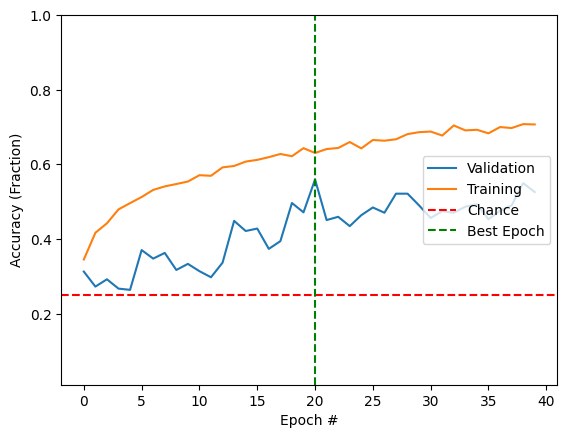

In [ ]:
# Creating the neural network model by specifying and compiling it

# Sequential type means information in network flows from
# left neurons to right neurons
model_3 = Sequential()

# flatten 64 x 64 pixel RGB images so there are 12288 input layer neurons
model_3.add(Flatten(input_shape = (64, 64, 3)))

# Dense: every neuron in current hidden layer receieves input from
# every neuron of previous layer, and outputs information to every neuron of next layer

# narrow to 128 neurons in hidden layer
# relu: gradient (1 or 0) so faster network flow, simplicity allows for training on deep networking,
# non-linear transformation/mapping allows for network learning features such as curves, edges, complex shapes, and abstract concepts
model_3.add(Dense(units=128, activation = 'relu'))

# 4 output layer neurons to classify images into the 4 classes
model_3.add(Dense(units=4, activation = 'softmax'))
model_3.compile(loss='categorical_crossentropy',
                optimizer = optimizers.SGD(learning_rate=1e-4, momentum=0.95),
                metrics = ['accuracy'])

model_3_answer = Sequential()
model_3_answer.add(Flatten(input_shape = (64, 64, 3)))
model_3_answer.add(Dense(units = 128, activation = 'relu'))
model_3_answer.add(Dense(units = 4, activation = 'softmax'))

model_3_answer.compile(loss='categorical_crossentropy',
              optimizer=optimizers.SGD(learning_rate=1e-4, momentum=0.95),
              metrics=['accuracy'])

if model_to_string(model_3) == model_to_string(model_3_answer):
  print('Good job, you specified it correctly!')
else:
  print('Please check your code again!')

# Define our monitor. Don't worry about the parameters here except for './model.h5',
# which is the file that our model saves to.
monitor = ModelCheckpoint(
    './model.keras',
    monitor='val_loss',
    verbose=0,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch'
)

# Create an instance of ImageDataGenerator for data augmentation
data_augmentation = ImageDataGenerator(
    rotation_range=10,  # Rotate images randomly up to 10 degrees
    width_shift_range=0.1,  # Shift images horizontally by a fraction of the width
    height_shift_range=0.1,  # Shift images vertically by a fraction of the height
    shear_range=0.2,  # Apply shear transformation with a shear angle up to 20 degrees
    zoom_range=0.2,  # Randomly zoom images by a factor up to 20%
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill in newly created pixels after rotation or shifting
)

# get the train data and test data
X_train, y_train = get_train_data()
X_test, y_test = get_test_data()

# Reshape the data
X_train = X_train.reshape([-1, 64, 64, 3])
X_test = X_test.reshape([-1, 64, 64, 3])

# Convert string labels into numpy arrays.
y_train = label_to_numpy(y_train)
y_test = label_to_numpy(y_test)

# fit your model
history = model_3.fit(data_augmentation.flow(X_train, y_train, batch_size=32), epochs = 40, validation_data = (X_test, y_test), shuffle = True, callbacks = [monitor])
plot_acc(history)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 221ms/step - accuracy: 0.2841 - loss: 1.3793 - val_accuracy: 0.3196 - val_loss: 1.3830
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 221ms/step - accuracy: 0.4422 - loss: 1.2350 - val_accuracy: 0.4250 - val_loss: 1.2116
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 45s 212ms/step - accuracy: 0.5658 - loss: 1.0482 - val_accuracy: 0.3207 - val_loss: 1.7163
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 47s 221ms/step - accuracy: 0.6107 - loss: 0.9576 - val_accuracy: 0.5793 - val_loss: 1.4445
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 45s 210ms/step - accuracy: 0.6430 - loss: 0.8894 - val_accuracy: 0.5587 - val_loss: 1.4678
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 46s 219ms/step - accuracy: 0.6859 - loss: 0.8087 - val_accuracy: 0.5598 - val_loss: 1.6155
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 46s 217ms/step - accuracy: 0.7153 - loss: 0.7500 - val_accuracy: 0.6011 - val_loss: 1.3878
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 45s 214ms/step - accuracy: 0.7497 - loss: 0

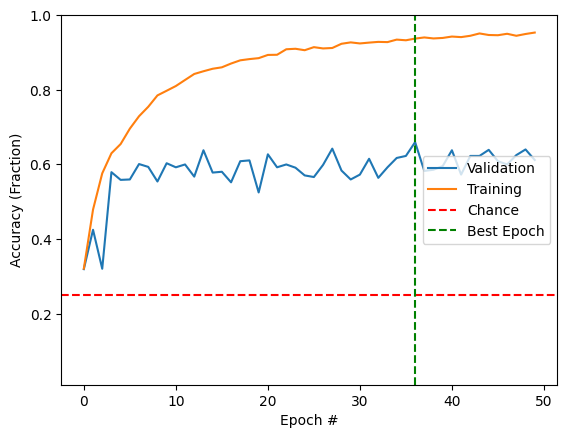

In [ ]:
cnn = Sequential()
cnn.add(Conv2D(64, (3, 3), input_shape=(64, 64, 3)))
cnn.add(Activation('relu'))
cnn.add(MaxPooling2D(pool_size=(2, 2)))
cnn.add(Flatten())
cnn.add(Dense(units = 64, activation = 'relu'))
cnn.add(Dense(units = 4, activation = 'softmax'))
cnn.compile(loss='categorical_crossentropy',
            optimizer=optimizers.SGD(learning_rate=1e-3, momentum=0.95),
            metrics=['accuracy'])
cnn.fit(data_augmentation.flow(X_train, y_train, batch_size=32), epochs = 50, validation_data = (X_test, y_test), shuffle = True, callbacks = [monitor])
plot_acc(cnn.history)

In [ ]:
(X_train, y_train) = get_train_data(flatten=True)
(X_test, y_test) = get_test_data(flatten=True)

X_train = X_train.reshape([-1, 64, 64, 3])
X_test = X_test.reshape([-1, 64, 64, 3])

y_train = label_to_numpy(y_train)
y_test = label_to_numpy(y_test)

transfer = TransferClassifier(name = 'VGG19')
transfer.layers[0].trainable = False
steps_per_epoch = len(X_train) // 32
transfer.fit(data_augmentation.flow(X_train, y_train, batch_size=32), steps_per_epoch=steps_per_epoch, epochs = 10, validation_data = (X_test, y_test), shuffle = True, callbacks = [monitor])
plot_acc(transfer.history)

Epoch 1/10
117/210 ━━━━━━━━━━━━━━━━━━━━ 2:46 2s/step - accuracy: 0.2732 - loss: 1.4474

KeyboardInterrupt: 